## import numpy as np
import re
import matplotlib.pyplot as plt 
from pathlib import Path
from shared import 

In [3]:
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:

folder = Path("global_steps")  # <-- set this

i_arr = []
population_arr = []
fitness_arr = []
aspect_arr = []
eps_conv_arr = []
eps_crit_arr = []
for f in sorted(folder.glob("step*.npy")):
    m = re.match(r"step(\d+)\.npy$", f.name)
    if m:
        content = np.load(f, allow_pickle=True).item()
        i_arr.append(int(m.group(1)))
        population_arr.append(content['population'])
        fitness_arr.append(content['fitness'])
        aspect_arr.append(content['data_dict']['aspect'])
        eps_conv_arr.append(content['data_dict']['eps_conv'])
        eps_crit_arr.append(content['data_dict']['eps_crit'])

In [23]:

folder = Path("pass_2/global_steps")  # <-- set this
for f in sorted(folder.glob("step*.npy")):
    m = re.match(r"step(\d+)\.npy$", f.name)
    if m:
        content = np.load(f, allow_pickle=True).item()
        i_arr.append(int(m.group(1)))
        population_arr.append(content['population'])
        fitness_arr.append(content['fitness'])
        aspect_arr.append(content['data_dict']['aspect'])
        eps_conv_arr.append(content['data_dict']['eps_conv'])
        eps_crit_arr.append(content['data_dict']['eps_crit'])

In [36]:
len(eps_conv_arr)

48

In [37]:
content['data_dict'].keys()

dict_keys(['anisotropy', 'aspect', 'eps_conv', 'eps_crit', 'iota_a', 'p_axis_eff', 'p_edge_eff'])

In [38]:
i_arr = np.array(i_arr)
population_arr = np.array(population_arr)
fitness_arr = np.array(fitness_arr)
aspect_arr = np.array(aspect_arr)
eps_conv_arr = np.array(eps_conv_arr)
eps_crit_arr = np.array(eps_crit_arr)

argsort_i = np.argsort(i_arr)
i_arr = i_arr[argsort_i]
population_arr = population_arr[argsort_i]
fitness_arr = fitness_arr[argsort_i]

Text(0, 0.5, 'Value')

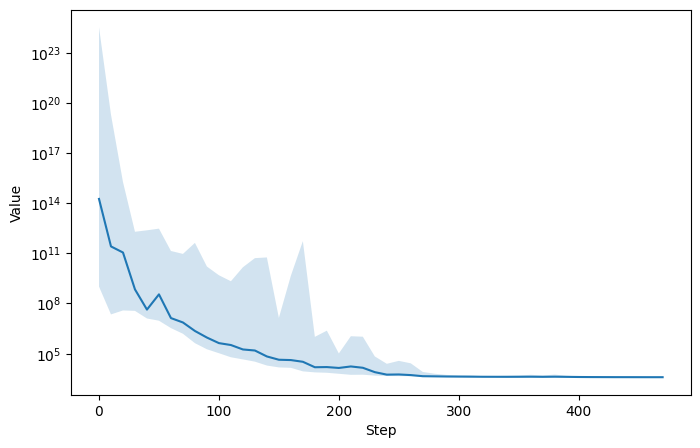

In [39]:
median = np.nanmedian(fitness_arr, axis=1)
p10 = np.nanpercentile(fitness_arr, 10, axis=1)
p90 = np.nanpercentile(fitness_arr, 90, axis=1)


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(i_arr, median)
ax.fill_between(i_arr, p10, p90, alpha=0.2)

ax.set_yscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Value")
# ax.legend()

In [40]:
fit_flat = fitness_arr.flatten()
aspect_flat = aspect_arr.flatten()
eps_conv_flat = eps_conv_arr.flatten()
eps_crit_flat = eps_crit_arr.flatten()
pop_flat = population_arr.reshape([len(fit_flat), -1])

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pop_projected = pca.fit_transform(pop_flat)  # shape: (n_sample, 2)
evr = pca.explained_variance_ratio_
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.375903   0.20120092]


In [42]:
pop_projected.shape

(9600, 2)

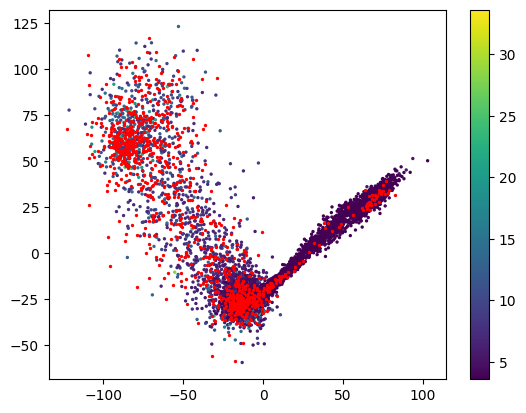

In [43]:
nan_mask_flat = np.argwhere(np.isnan(fit_flat))
plt.scatter(
    pop_projected[:, 0], pop_projected[:, 1], 
    s=2,
    c=np.log10(fit_flat),
)
plt.colorbar()
plt.scatter(
    pop_projected[nan_mask_flat, 0], pop_projected[nan_mask_flat, 1], 
    s=2,
    c='red',
)

<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:10: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:10: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2108361/628314055.py:9: SyntaxWarning: invalid escape sequence '\%'
  plt.xlabel(f'1st principle component ($EVR={int(100*evr[0])}\%$)')
/tmp/ipykernel_2108361/628314055.py:10: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel(f'2nd principle component ($EVR={int(100*evr[1])}\%$)')


Text(0, 0.5, '2nd principle component ($EVR=11\\%$)')

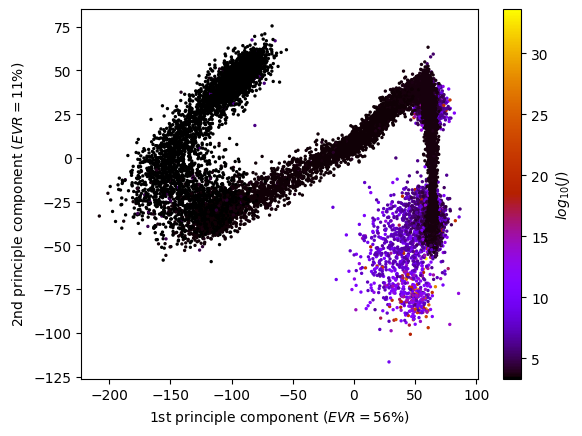

In [32]:
nan_mask_flat = np.argwhere(np.isnan(fit_flat))
plt.scatter(
    pop_projected[:, 0], pop_projected[:, 1], 
    s=2,
    c=np.log10(fit_flat),
    cmap='gnuplot'
)
plt.colorbar(label='$log_{10}(J)$')
plt.xlabel(f'1st principle component ($EVR={int(100*evr[0])}\%$)')
plt.ylabel(f'2nd principle component ($EVR={int(100*evr[1])}\%$)')
# plt.scatter(
#     pop_projected[nan_mask_flat, 0], pop_projected[nan_mask_flat, 1], 
#     # s=6,
#     marker='x',
#     c='black',
#     alpha=0.2
# )

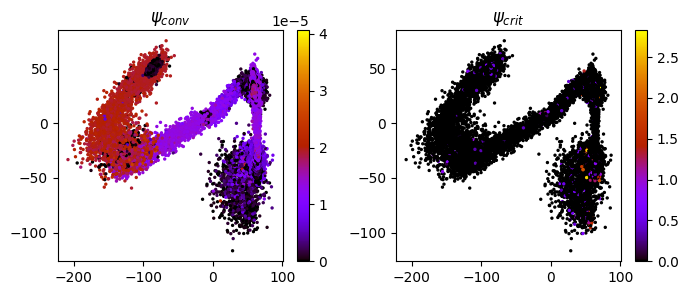

In [33]:
clim_eps = None  #0.004**2
alpha = 1
cmap = 'gnuplot'
nan_mask_flat = np.argwhere(np.isnan(fit_flat))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.scatter(
    pop_projected[:, 0], pop_projected[:, 1], 
    s=2,
    c=eps_conv_flat**2,
    alpha=alpha,
    cmap=cmap,
)
# plt.clim(0, clim_eps)
plt.title(r'$\psi_{conv}$')
plt.colorbar()
plt.subplot(1,2,2)
plt.scatter(
    pop_projected[:, 0], pop_projected[:, 1], 
    s=2,
    c=eps_crit_flat**2,
    alpha=alpha,
    cmap=cmap,
)
# plt.clim(0, clim_eps)
plt.title(r'$\psi_{crit}$')
plt.colorbar()

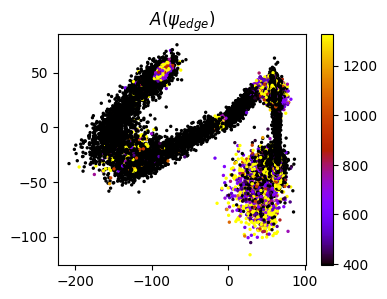

In [34]:
clim_eps = None  #0.004**2
alpha = 1
cmap = 'gnuplot'
nan_mask_flat = np.argwhere(np.isnan(fit_flat))
plt.figure(figsize=(4,3))
plt.scatter(
    pop_projected[:, 0], pop_projected[:, 1], 
    s=2,
    c=aspect_flat,
    alpha=alpha,
    cmap=cmap,
)
plt.clim(np.nanmin(aspect_flat*2), np.nanmedian(aspect_flat*5))
plt.title(r'$A(\psi_{edge})$')
plt.colorbar()